## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import pickle
import os
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision.models import convnext_base, ConvNeXt_Base_Weights, resnet18, ResNet18_Weights
import matplotlib.pyplot as plt

from data.datasets import DeepFakeDataset
from torch.utils.tensorboard import SummaryWriter

from torcheval.metrics.functional import binary_auroc, binary_auprc

2025-07-10 04:36:05.762289: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752122165.782374   54750 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752122165.788491   54750 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752122165.804382   54750 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752122165.804397   54750 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752122165.804399   54750 computation_placer.cc:177] computation placer alr

In [2]:
image_dir_path = 'Deepfake-Eval-2024/image-data'
model_type = 'ConvNeXt'

# small subset of training data to run on CPU and debug functional issues
debug_data = DeepFakeDataset("image-metadata-debug.csv", image_dir_path, model_type, is_train = True)
debug_data_loader = DataLoader(debug_data, batch_size = 32, shuffle = False)

model = convnext_base(weights = ConvNeXt_Base_Weights.DEFAULT)
# model = resnet18(weights = ResNet18_Weights.DEFAULT)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].


torch.Size([32, 1000])


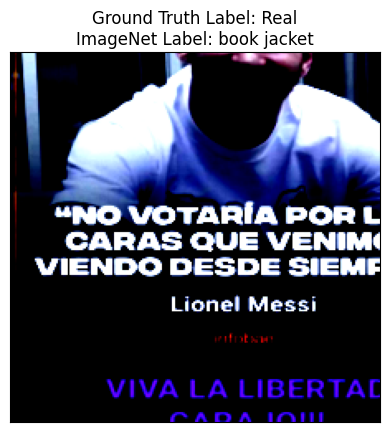

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].


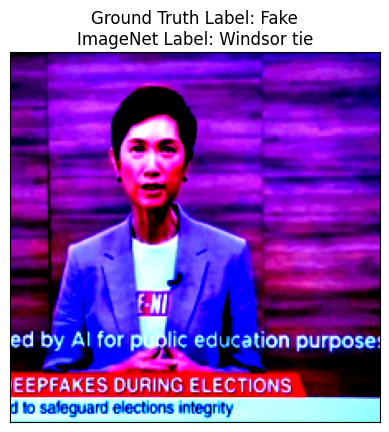

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].


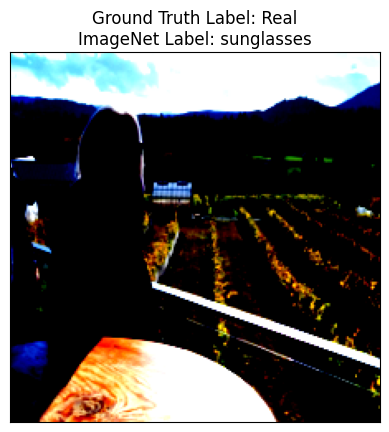

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


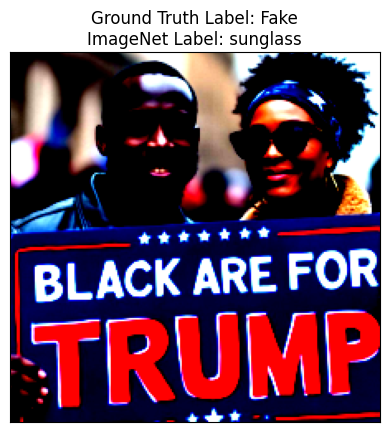

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].


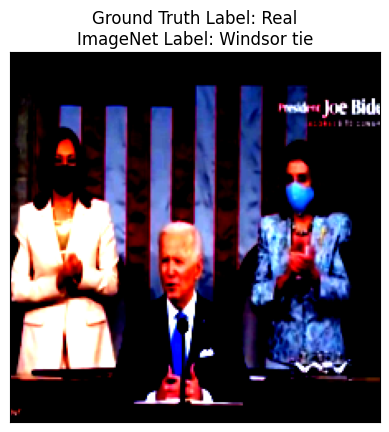

In [3]:
count = 0
features, label = next(iter(debug_data_loader))
with torch.no_grad():
    model_output = model(features)
    print(model_output.shape)

for i in range(5):

    img = features[i]
    # print(predictions[0].argmax(-1).item())
    imagenet_label = ResNet18_Weights.DEFAULT.meta['categories'][model_output[i].argmax(-1).item()]

    plt.imshow(np.transpose(img, (1,2,0))) # convert pytorch tensor (3 channels, H, W) to numpy array (H, W, 3 channels)
    plt.title(f"Ground Truth Label: {'Fake' if label[i] else 'Real'}\nImageNet Label: {imagenet_label}")
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [4]:
# modify ConvNeXtclassifier head for deepfake detection
classifier_head_layers = [layer for layer in model.classifier]
classifier_head_layers[2] = nn.Linear(in_features=1024, out_features=2, bias = True)
model.classifier = nn.Sequential(*classifier_head_layers)

In [5]:
# # modify ResNet classifier head for deepfake detection
# model.fc = nn.Linear(in_features = 512, out_features=2, bias = True)

# # # freeze all model parameters
# # for param in model.parameters():
# #     param.requires_grad = False

# # # unfreeze parameters (i.e. coefficients) in classifier head
# # for param in model.fc.parameters():
# #     param.requires_grad = True

In [6]:
torch.cuda.get_device_name(0)

'Tesla T4'

In [7]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to("cuda")
learning_rate = 1e-3
batch_size = 32
epochs = 3
loss_fn = nn.CrossEntropyLoss(reduction = 'sum')
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
# optimizer = torch.optim.LBFGS(model.parameters(), max_iter = 5, history_size = 10)

In [8]:
train_data = DeepFakeDataset("image-metadata-train.csv", image_dir_path, model_type, is_train = True)
train_data_loader = DataLoader(train_data, batch_size = batch_size, shuffle = True)

val_data = DeepFakeDataset("image-metadata-val.csv", image_dir_path, model_type, is_train = True)
val_data_loader = DataLoader(val_data, batch_size = batch_size, shuffle = True)


In [9]:
def train_epoch(dataloader, model, loss_fn, optimizer):
    # learn the weights
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # move data to GPU
        X = X.to('cuda')
        y = y.to('cuda')

        # forward pass
        pred = model(X)
        loss = loss_fn(pred, y)

        # backward pass
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        current = batch * batch_size + len(X)
        print(f"\t[{current:>5d}/{len(dataloader.dataset):>5d}]")

    return validate_epoch(dataloader, model, loss_fn)

def validate_epoch(dataloader, model, loss_fn):
    model.eval()
    val_loss = 0
    all_preds = torch.zeros((0,2)).to('cuda')
    all_labels = torch.zeros(0).to('cuda')
    
    with torch.no_grad():
        for X, y in dataloader:
            # move data to GPU
            X = X.to('cuda')
            y = y.to('cuda')

            pred = model(X)
            all_preds = torch.cat((all_preds, pred), dim = 0)
            all_labels = torch.cat((all_labels, y), dim = 0)
            val_loss += loss_fn(pred, y).item()


    val_auroc = binary_auroc(all_preds[:,1], all_labels)
    val_auprc = binary_auprc(all_preds[:,1], all_labels)
    val_loss /= len(dataloader.dataset)

    return val_loss, val_auroc, val_auprc

In [10]:
# writer = SummaryWriter()
train_loss_, train_auroc_, train_auprc_, val_loss_, val_auroc_, val_auprc_ = [None] * epochs, [None] * epochs, [None] * epochs, [None] * epochs, [None] * epochs, [None] * epochs
for t in range(epochs):
    print(f"Epoch {t+1}\n- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - ")
    train_loss, train_auroc, train_auprc = train_epoch(train_data_loader, model, loss_fn, optimizer)
    val_loss, val_auroc, val_auprc = validate_epoch(val_data_loader, model, loss_fn)
#     writer.add_scalar('training loss', train_loss, t)
#     writer.add_scalar('validation loss', val_loss, t)
#     writer.add_scalar('training roc auc', train_auroc, t)
#     writer.add_scalar('validation roc auc', val_auroc, t)
#     writer.add_scalar('training pr auc', train_auprc, t)
#     writer.add_scalar('validation pr auc', val_auprc, t)
    print(f"Training Error: \n\tLoss: {train_loss:>8f}\tROC AUC: {train_auroc:>4f}\tPR AUC: {train_auprc:>4f} \n")
    print(f"Validation Error: \n\tLoss: {val_loss:>8f}\tROC AUC: {val_auroc:>4f}\tPR AUC: {val_auprc:>4f} \n")
    train_loss_[t], train_auroc_[t], train_auprc_[t], val_loss_[t], val_auroc_[t], val_auprc_[t] = train_loss, train_auroc, train_auprc, val_loss, val_auroc, val_auprc
    # writer.close()
print("Done!")

Epoch 1
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
	[   32/ 1365]
	[   64/ 1365]
	[   96/ 1365]
	[  128/ 1365]
	[  160/ 1365]
	[  192/ 1365]
	[  224/ 1365]
	[  256/ 1365]
	[  288/ 1365]
	[  320/ 1365]
	[  352/ 1365]
	[  384/ 1365]
	[  416/ 1365]
	[  448/ 1365]
	[  480/ 1365]
	[  512/ 1365]
	[  544/ 1365]
	[  576/ 1365]
	[  608/ 1365]
	[  640/ 1365]
	[  672/ 1365]
	[  704/ 1365]
	[  736/ 1365]
	[  768/ 1365]
	[  800/ 1365]
	[  832/ 1365]
	[  864/ 1365]
	[  896/ 1365]
	[  928/ 1365]
	[  960/ 1365]
	[  992/ 1365]
	[ 1024/ 1365]
	[ 1056/ 1365]
	[ 1088/ 1365]
	[ 1120/ 1365]
	[ 1152/ 1365]
	[ 1184/ 1365]
	[ 1216/ 1365]
	[ 1248/ 1365]
	[ 1280/ 1365]
	[ 1312/ 1365]
	[ 1344/ 1365]
	[ 1365/ 1365]
Training Error: 
	Loss: 0.667732	ROC AUC: 0.597737	PR AUC: 0.679752 

Validation Error: 
	Loss: 0.668775	ROC AUC: 0.545880	PR AUC: 0.635041 

Epoch 2
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
	[   32/ 1365]
	[   64/ 1365]
	[   96/ 1365]
	[  128/ 1365]
	[  160/ 1365]


In [11]:
with open(f"train_progress.pkl", "wb") as f:
    pickle.dump((train_loss_, train_auroc_, train_auprc_, val_loss_, val_auroc_, val_auprc_), f)
    f.close()

In [12]:

with open("train_progress.pkl", "rb") as f:
    train_loss_, train_auroc_, train_auprc_, val_loss_, val_auroc_, val_auprc_ = pickle.load(f)

In [13]:
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman']
# plt.rcParams['font.size'] = 10
# plt.rcParams["axes.formatter.use_mathtext"] = True
# plt.rcParams["text.usetex"] = True

In [20]:
train_auroc_

[tensor(0.5977, device='cuda:0', dtype=torch.float64),
 tensor(0.6169, device='cuda:0', dtype=torch.float64),
 tensor(0.6307, device='cuda:0', dtype=torch.float64)]

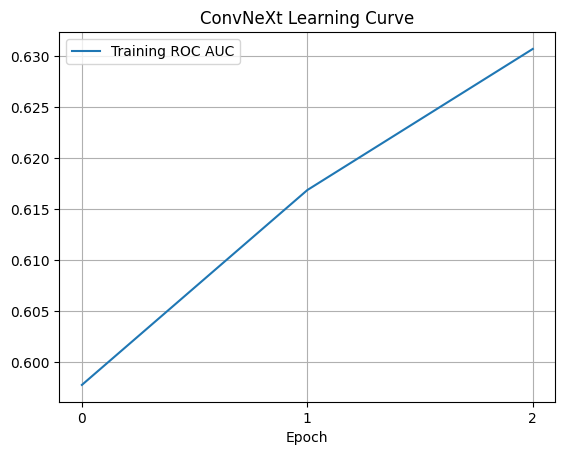

In [ ]:
plt.title("ConvNeXt Learning Curve")
plt.plot([i.item() for i in train_auroc_], label = 'Training ROC AUC')
plt.plot([i.item() for i in val_auroc_], label = 'Validation ROC AUC')
plt.xlabel("Epoch")
plt.grid(axis = 'both')
plt.xticks([0,1,2])
plt.legend()
plt.show()